In [1]:
!nvidia-smi

Sun Oct  5 22:15:55 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.163.01             Driver Version: 550.163.01     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          On  |   00000000:03:00.0 Off |                    0 |
| N/A   30C    P0             53W /  400W |       1MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [ ]:
from gigalens.jax.inference import ModellingSequence
from gigalens.jax.model import ForwardProbModel, BackwardProbModel
from gigalens.model import PhysicalModel
from gigalens.jax.simulator import LensSimulator
from gigalens.simulator import SimulatorConfig
from gigalens.jax.profiles.light import sersic
from gigalens.jax.profiles.mass import epl, shear
from corner import corner

import tensorflow_probability.substrates.jax as tfp
import jax
from jax import random
import numpy as np
import optax
from jax import numpy as jnp
from matplotlib import pyplot as plt
import optax
tfd = tfp.distributions

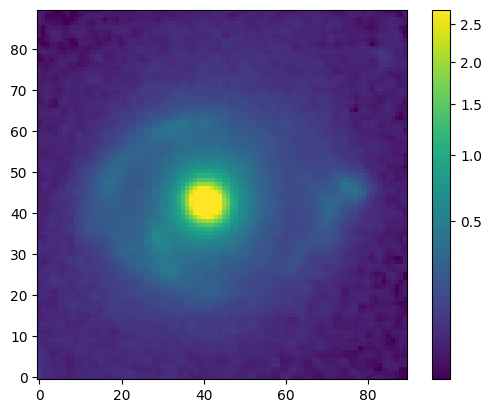

In [3]:
from astropy.io import fits
from astropy.visualization import simple_norm
import matplotlib.pyplot as plt
import numpy as np

data94 = fits.open("final_94_drz.fits")
image94 = data94[1].data
data94.close()
#image94[image94<0] = 0
image_size = 80
lens_x=1227
lens_y=1070
system = image94[(int)(lens_y-image_size/2):(int)(lens_y+image_size/2),(int)(lens_x-image_size/2):(int)(lens_x+image_size/2)]

norm = simple_norm(system, "sqrt", percent=99.)
plt.imshow(system, norm=norm, cmap="viridis", origin='lower')
plt.colorbar()

epsfdata = fits.open("psf94.fits")
epsf = epsfdata[0].data
epsfdata.close()

In [4]:
lens_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                theta_E=tfd.LogNormal(jnp.log(1.5), 0.25),
                gamma=tfd.TruncatedNormal(2, 0.25, 1, 3),
                e1=tfd.Normal(0, 0.1),
                e2=tfd.Normal(0, 0.1),
                center_x=tfd.Normal(-0.2, 0.05),
                center_y=tfd.Normal(-0.2, 0.05),
            )
        ),
        tfd.JointDistributionNamed(
            dict(gamma1=tfd.Normal(0, 0.15), gamma2=tfd.Normal(0, 0.15))
        ),
    ]
)
lens_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(1.0), 0.15),
                n_sersic=tfd.Uniform(2, 6),
                e1=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                e2=tfd.TruncatedNormal(0, 0.1, -0.3, 0.3),
                center_x=tfd.Normal(0, 0.05),
                center_y=tfd.Normal(0, 0.05),
                Ie=tfd.LogNormal(jnp.log(100), 0.3),
            )
        )
    ]
)

source_light_prior = tfd.JointDistributionSequential(
    [
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(-0.2, 0.25),
                center_y=tfd.Normal(-0.2, 0.25),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        ), 
        tfd.JointDistributionNamed(
            dict(
                R_sersic=tfd.LogNormal(jnp.log(0.25), 0.15),
                n_sersic=tfd.Uniform(0.5, 4),
                e1=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                e2=tfd.TruncatedNormal(0, 0.15, -0.5, 0.5),
                center_x=tfd.Normal(0, 0.25),
                center_y=tfd.Normal(0, 0.25),
                Ie=tfd.LogNormal(jnp.log(30), 0.5),
            )
        )
    ]
)

prior = tfd.JointDistributionSequential(
    [lens_prior, lens_light_prior, source_light_prior]
)

In [5]:
kernel = np.array(epsf).astype(np.float32)
sim_config = SimulatorConfig(delta_pix=0.065, num_pix=90, supersample=2, kernel=kernel)
phys_model = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False), sersic.SersicEllipse(use_lstsq=False)])
lens_sim = LensSimulator(phys_model, sim_config, bs=1)
observed_img = system
background_rms = 0.007616264 #background_rms calculated using photutils.background
prob_model = ForwardProbModel(prior, observed_img, background_rms=background_rms, exp_time=100)
model_seq = ModellingSequence(phys_model, prob_model, sim_config)

In [6]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-2, end_value=-1e-2/3, 
                                      power=0.5, transition_steps=500)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
map_estimate = model_seq.MAP(opt, seed=0)

Chi-squared: 0.334: 100%|██████████| 350/350 [00:35<00:00,  9.99it/s]


In [7]:
lps = prob_model.log_prob(LensSimulator(phys_model, sim_config, bs=500), map_estimate)[0]
best = map_estimate[jnp.argmax(lps)][jnp.newaxis,:]

In [8]:
schedule_fn = optax.polynomial_schedule(init_value=-1e-6, end_value=-3e-3, 
                                      power=2, transition_steps=300)
opt = optax.chain(
  optax.scale_by_adam(),
  optax.scale_by_schedule(schedule_fn),
)
qz, loss_hist = model_seq.SVI(best, opt, n_vi=1000, num_steps=2000)

ELBO: -20397.205: 100%|██████████| 2000/2000 [03:02<00:00, 10.95it/s]


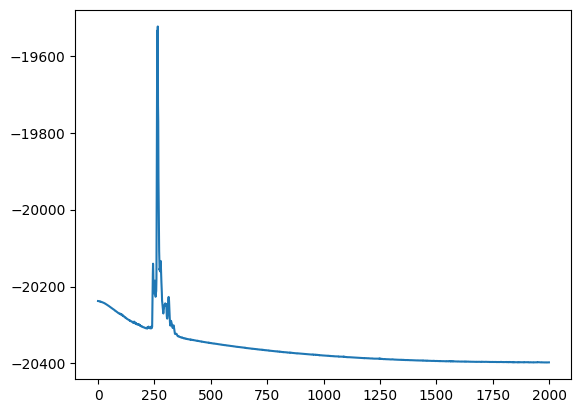

In [9]:
plt.plot(loss_hist)

In [10]:
samples = model_seq.HMC(qz, num_burnin_steps=250, num_results=750)

Sampling took 30.7s


In [11]:
rhat= tfp.mcmc.potential_scale_reduction(jnp.transpose(samples.all_states, (1,2,0,3)), independent_chain_ndims=2)
ess = tfp.mcmc.effective_sample_size(jnp.transpose(samples.all_states, (1,2,0,3)), cross_chain_dims=[1,2])
numParams = len(rhat)
for i in range(0,numParams):
    print(rhat[i], ess[i])

1.0001632 29253.006
1.0000871 27908.855
1.0001961 27383.201
1.0009716 24315.727
1.0020863 15740.655
1.0009478 27957.44
1.0007472 25753.549
1.0015224 17420.748
1.0182241 2150.933
1.0160254 2444.3567
1.0008038 28416.383
1.0032377 26805.773
0.9997286 30995.035
1.0002273 30575.645
1.0783685 602.87695
0.99971384 28484.838
1.0017009 19608.541
1.0014622 20539.604
1.0000976 27329.477
1.0000337 30383.19
1.0004646 30051.21
1.0001333 27726.139
1.0020434 26826.887
1.0005599 27169.443
1.00208 16788.953
1.0016893 20560.834
1.0001947 25566.896
0.99986726 27384.547
1.0375953 1469.8813


In [12]:
smp = jnp.transpose(samples.all_states, (1, 2, 0, 3)).reshape((-1, numParams))
smp_physical = prob_model.bij.forward(list(smp.T))

def get_corner_samples(physical, key):
    """
    Key tells you lens_mass (1), lens_light (2), or source_light (3)
    """
    return_list = []

    if key == 1:
        for i in physical[0][0].keys():
            return_list.append(physical[0][0][i])
        for j in physical[0][1].keys():
            return_list.append(physical[0][1][j])

    if key == 2:
        for i in physical[1][0].keys():
            return_list.append(physical[1][0][i])

    if key == 3:
        for i in physical[2][0].keys():
            return_list.append(physical[2][0][i])
            
    return np.stack(return_list).T

mass_samps = get_corner_samples(smp_physical, 1)
median_params = [
    [
        {key: np.median(value) for key, value in d.items()}
        for d in list_of_dicts
    ]
    for list_of_dicts in smp_physical
]
import pprint
pprint.pprint(median_params)

[[{'center_x': -0.25988573,
   'center_y': -0.14213598,
   'e1': 0.0013503677,
   'e2': 0.022193365,
   'gamma': 1.9829234,
   'theta_E': 1.4741846},
  {'gamma1': 0.15580586, 'gamma2': -0.020275787}],
 [{'Ie': 26.489172,
   'R_sersic': 1.4714035,
   'center_x': -0.24902755,
   'center_y': -0.122597225,
   'e1': -0.0485408,
   'e2': 0.0732726,
   'n_sersic': 5.817461}],
 [{'Ie': 20.550186,
   'R_sersic': 0.24110323,
   'center_x': -0.05960922,
   'center_y': -0.1562565,
   'e1': -0.077090025,
   'e2': 0.17085105,
   'n_sersic': 0.96297234},
  {'Ie': 63.851006,
   'R_sersic': 0.090480596,
   'center_x': 0.27160305,
   'center_y': 0.018893532,
   'e1': 0.21146812,
   'e2': 0.0033820868,
   'n_sersic': 0.58057594}]]


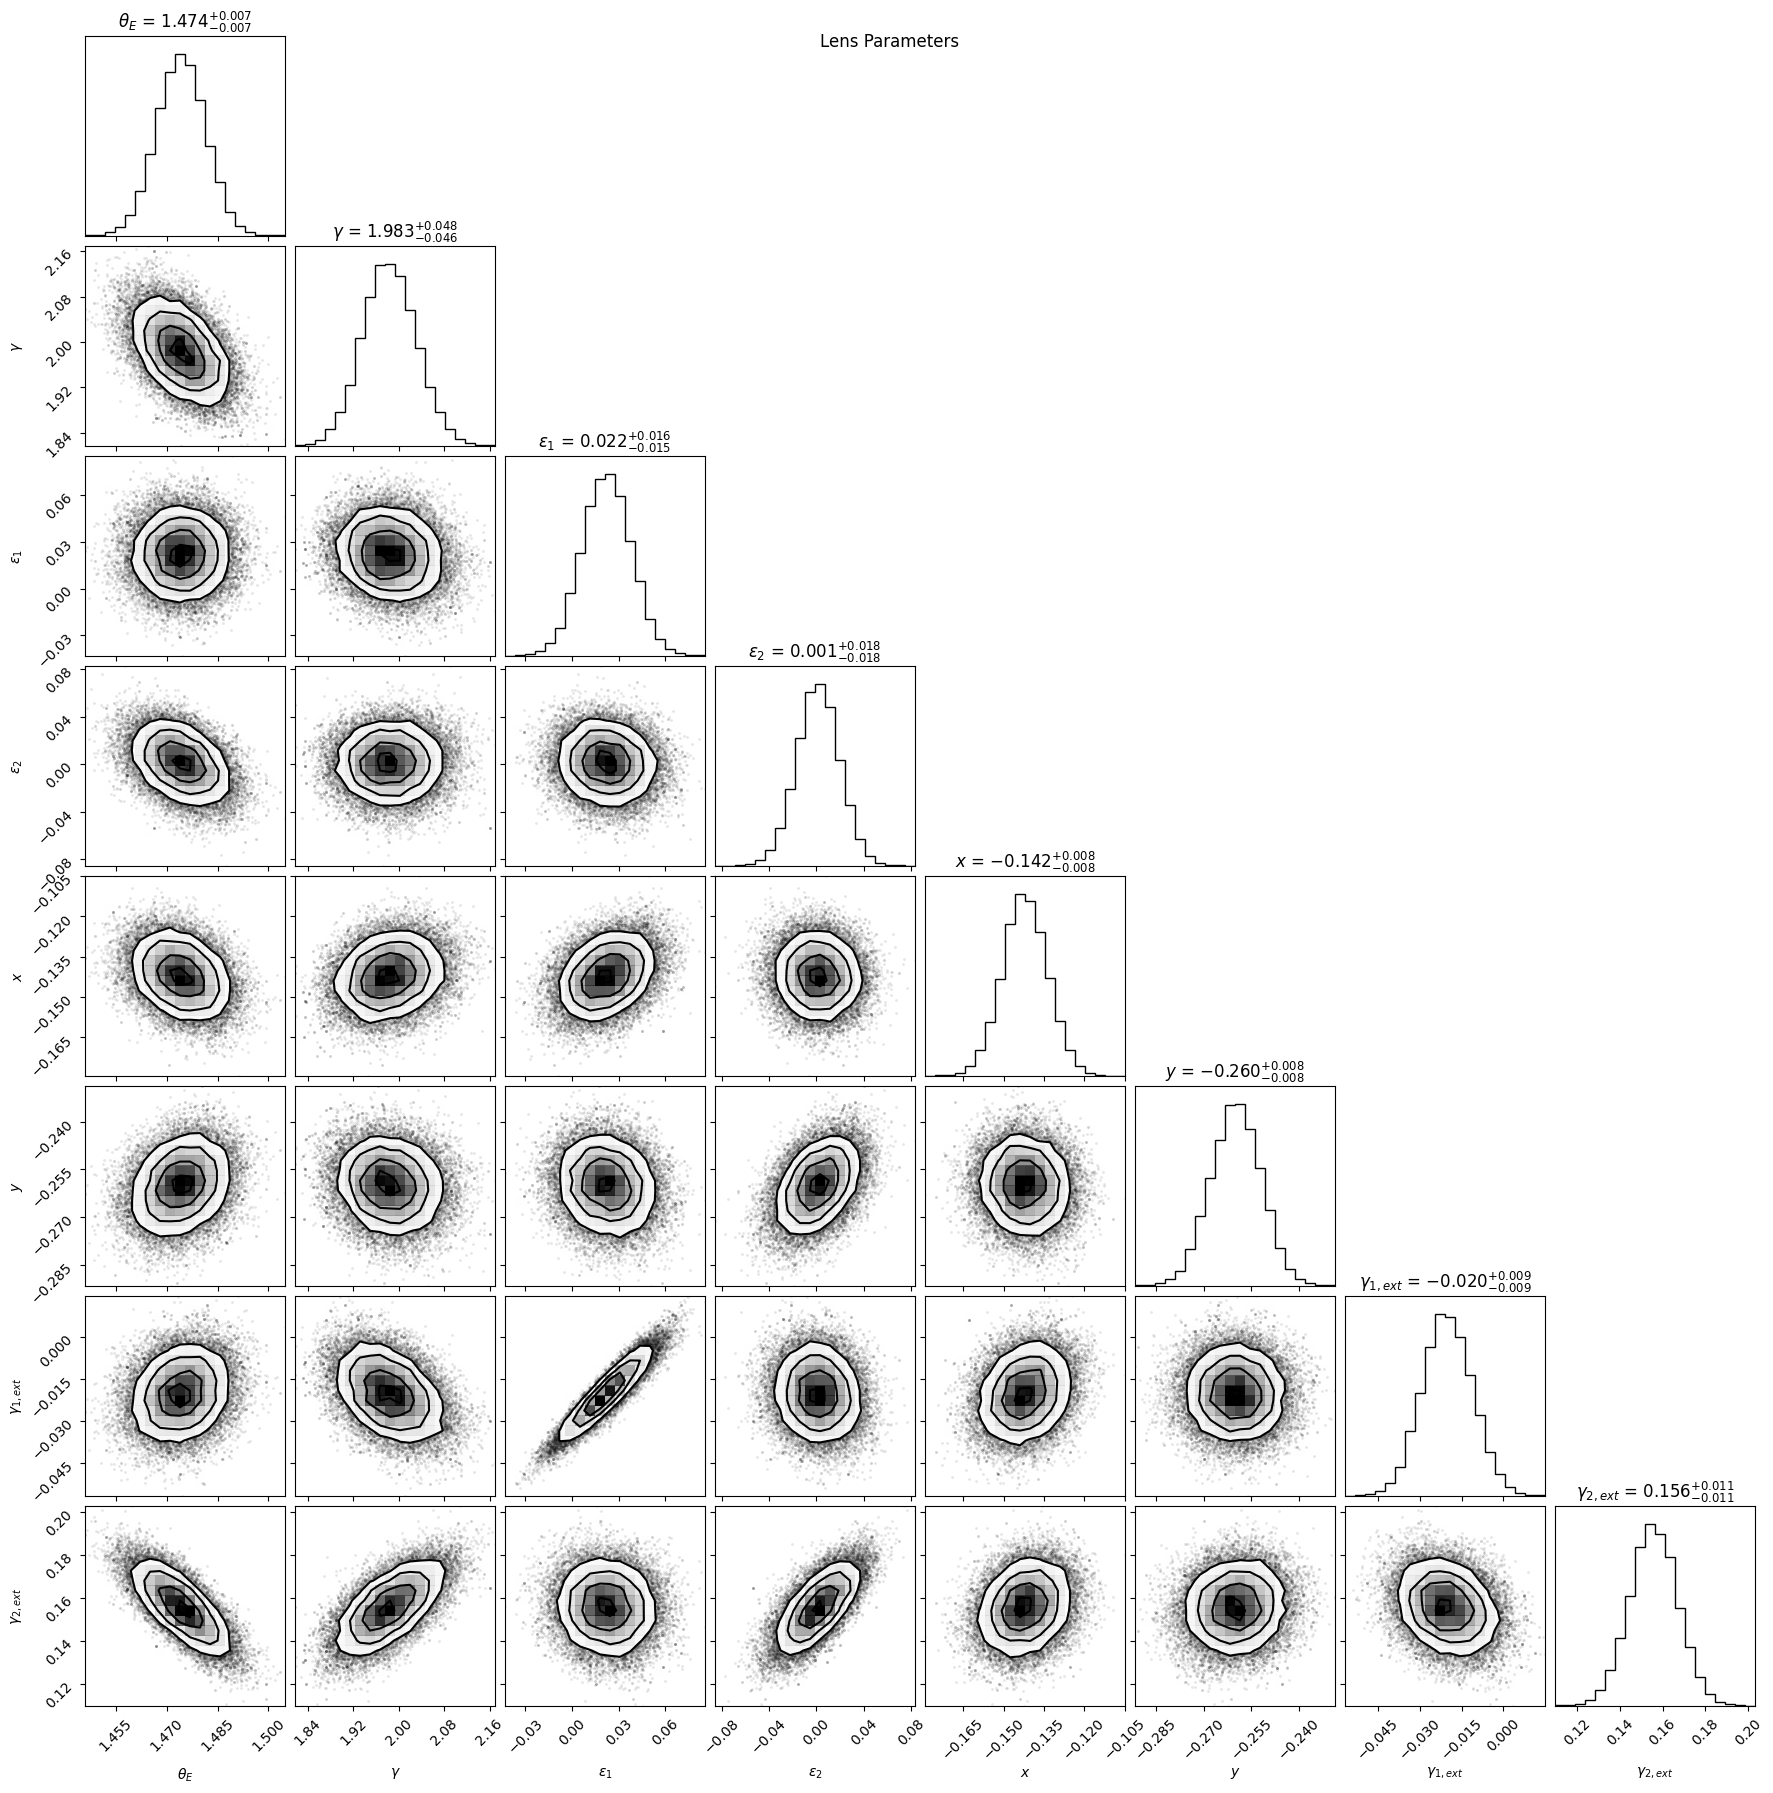

In [13]:
plt.style.use('default')

labels=[r'$\theta_E$', 
        r'$\gamma$', 
        r'$\epsilon_1$', 
        r'$\epsilon_2$', 
        r'$x$', r'$y$', 
        r'$\gamma_{1,ext}$', 
        r'$\gamma_{2,ext}$']

fig = corner(mass_samps, show_titles=True, title_fmt='.3f', labels=labels)
_ = fig.suptitle("Lens Parameters")

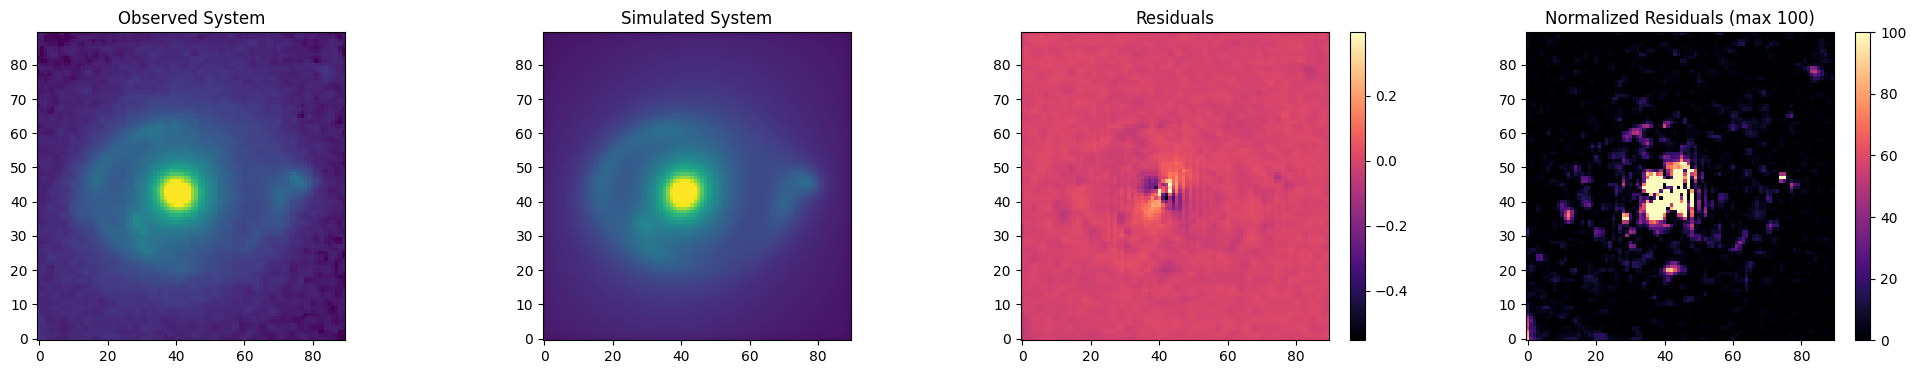

In [20]:
simulated = lens_sim.simulate(median_params)
residual = simulated - jnp.array(system, dtype=jnp.float32)
norm_residual = np.square(residual) / np.square(background_rms)
fig, ax = plt.subplots(1,4, figsize=(25,4))
image_sys = ax[0].imshow(system, norm=norm, cmap="viridis", origin='lower')
image_sim = ax[1].imshow(simulated, norm=norm, cmap="viridis", origin='lower')
image_res = ax[2].imshow(residual, cmap="magma", origin='lower')
image_nres = ax[3].imshow(norm_residual, cmap="magma", origin='lower', vmin=0, vmax=100)
ax[0].set_title("Observed System")
ax[1].set_title("Simulated System")
ax[2].set_title("Residuals")
ax[3].set_title("Normalized Residuals (max 100)")
plt.colorbar(image_res)
plt.colorbar(image_nres)
plt.show()

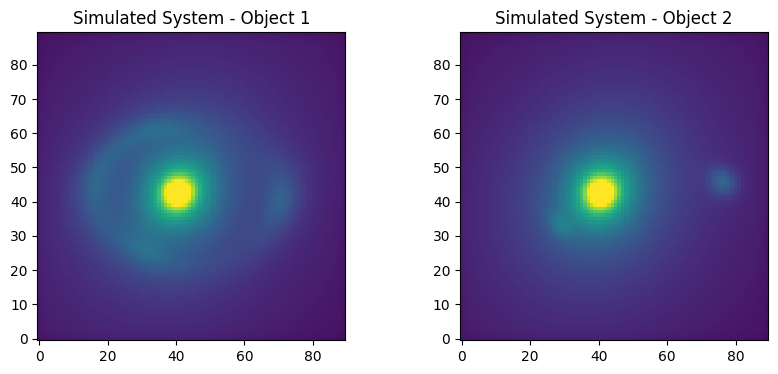

In [23]:
phys_model2 = PhysicalModel([epl.EPL(50), shear.Shear()], [sersic.SersicEllipse(use_lstsq=False)], [sersic.SersicEllipse(use_lstsq=False)])
lens_sim2 = LensSimulator(phys_model2, sim_config, bs=1)
obj1 = [[{'center_x': -0.25988573,
   'center_y': -0.14213598,
   'e1': 0.0013503677,
   'e2': 0.022193365,
   'gamma': 1.9829234,
   'theta_E': 1.4741846},
  {'gamma1': 0.15580586, 'gamma2': -0.020275787}],
 [{'Ie': 26.489172,
   'R_sersic': 1.4714035,
   'center_x': -0.24902755,
   'center_y': -0.122597225,
   'e1': -0.0485408,
   'e2': 0.0732726,
   'n_sersic': 5.817461}],
 [{'Ie': 20.550186,
   'R_sersic': 0.24110323,
   'center_x': -0.05960922,
   'center_y': -0.1562565,
   'e1': -0.077090025,
   'e2': 0.17085105,
   'n_sersic': 0.96297234}]]
simulatedobj1 = lens_sim2.simulate(obj1)
obj2 = [[{'center_x': -0.25988573,
   'center_y': -0.14213598,
   'e1': 0.0013503677,
   'e2': 0.022193365,
   'gamma': 1.9829234,
   'theta_E': 1.4741846},
  {'gamma1': 0.15580586, 'gamma2': -0.020275787}],
 [{'Ie': 26.489172,
   'R_sersic': 1.4714035,
   'center_x': -0.24902755,
   'center_y': -0.122597225,
   'e1': -0.0485408,
   'e2': 0.0732726,
   'n_sersic': 5.817461}],
 [{'Ie': 63.851006,
   'R_sersic': 0.090480596,
   'center_x': 0.27160305,
   'center_y': 0.018893532,
   'e1': 0.21146812,
   'e2': 0.0033820868,
   'n_sersic': 0.58057594}]]
simulatedobj2 = lens_sim2.simulate(obj2)
fig, ax = plt.subplots(1,2, figsize=(10,4))
simobj1 = ax[0].imshow(simulatedobj1, norm=norm, cmap="viridis", origin='lower')
simobj2 = ax[1].imshow(simulatedobj2, norm=norm, cmap="viridis", origin='lower')
ax[0].set_title("Simulated System - Object 1")
ax[1].set_title("Simulated System - Object 2")
plt.show()